# Seasonal Clustering - K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
**Goal:** Apply K-Means clustering using seasonal weather features to discover whether electricity price patterns naturally align with meteorological seasons.

Features used (seasonal angle only):
- `temperature_2m` - drives heating/cooling demand
- `shortwave_radiation` - proxy for solar generation potential
- `cloud_cover` - affects solar output and demand
- `wind_speed_10m` - proxy for wind generation potential
- `price` - economic outcome shaped by the above

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df = df.set_index('time').sort_index()

print(f'Rows: {len(df):,}  ({df.index.min().date()} — {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')

Rows: 96,133  (2015-01-04 — 2025-12-31)
Columns: ['price', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'total_load', 'generation_forecast']


## 2. Derive Season Labels

Meteorological seasons by month:

| Season | Months |
|--------|--------|
| Winter | Dec, Jan, Feb |
| Spring | Mar, Apr, May |
| Summer | Jun, Jul, Aug |
| Autumn | Sep, Oct, Nov |

In [2]:
def month_to_season(month):
    if month in (12, 1, 2):  return 'Winter'
    if month in (3, 4, 5):   return 'Spring'
    if month in (6, 7, 8):   return 'Summer'
    return 'Autumn'

df['season'] = df['month'].apply(month_to_season)

SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
SEASON_COLORS = {'Winter': '#5b9bd5', 'Spring': '#70ad47', 'Summer': '#ffc000', 'Autumn': '#ed7d31'}
CLUSTER_COLORS = ['#5b9bd5', '#70ad47', '#ffc000', '#ed7d31']

print(df.groupby('season')['price'].agg(['count', 'mean', 'std']).round(2).loc[SEASON_ORDER])

        count   mean    std
season                     
Winter  23665  80.27  73.54
Spring  24180  64.43  63.45
Summer  24288  78.49  96.36
Autumn  24000  83.68  76.85


## 3. Select Features and Scale

In [3]:
SEASONAL_FEATURES = [
    'temperature_2m',
    'shortwave_radiation',
    'cloud_cover',
    'wind_speed_10m',
    'price',
]

X = df[SEASONAL_FEATURES].dropna().copy()
season_labels = df.loc[X.index, 'season']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Clustering matrix: {X_scaled.shape}')
print('\nFeature statistics (original scale):')
print(X.describe().round(2))

Clustering matrix: (96133, 5)

Feature statistics (original scale):
       temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
count        96133.00             96133.00     96133.00        96133.00   
mean            11.08               129.16         0.67           14.25   
std              6.61               196.02         0.32            6.69   
min            -11.92                 0.00         0.00            1.80   
25%              6.16                 0.00         0.43            9.12   
50%             10.84                 5.80         0.76           13.02   
75%             15.90               203.40         0.97           18.06   
max             36.18               886.20         1.00           53.66   

          price  
count  96133.00  
mean      76.69  
std       78.85  
min     -500.00  
25%       34.14  
50%       49.71  
75%       92.27  
max      872.96  


## 4. Elbow Method - Choose k

The elbow plot shows within-cluster sum of squares (inertia) for k = 2…9. The bend in the curve indicates the optimal number of clusters. We expect k = 4 to correspond to the four seasons.

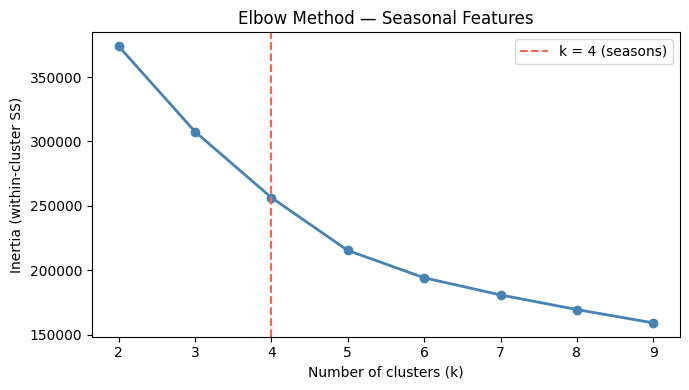

In [4]:
inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.axvline(4, linestyle='--', color='tomato', label='k = 4 (seasons)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow Method — Seasonal Features')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Fit K-Means (k = 4)

In [5]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km4.fit_predict(X_scaled)

# Keep the original clustering features plus a few extra variables
# that are useful for later statistical analysis.
X_result = df.loc[X.index, [
    'price',
    'temperature_2m',
    'shortwave_radiation',
    'cloud_cover',
    'wind_speed_10m',
    'total_load',
    'generation_forecast',
]].copy()

X_result['cluster'] = labels
X_result['season'] = season_labels.loc[X.index]

# Cluster centroids in original units
centroids = pd.DataFrame(
    scaler.inverse_transform(km4.cluster_centers_),
    columns=SEASONAL_FEATURES,
).round(2)
centroids.index.name = 'Cluster'
print('Cluster centroids (original scale):')
print(centroids)


Cluster centroids (original scale):
         temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
Cluster                                                                     
0                  9.39                48.13         0.89           16.58   
1                 10.35                85.13         0.69           10.82   
2                 18.52               469.91         0.59           14.47   
3                  8.94                39.76         0.32           10.87   

          price  
Cluster          
0         61.69  
1        305.10  
2         50.10  
3         65.06  


## 6. Visualise Clusters

Two scatter plots side by side:
- **Temperature vs Price** - shows how price separates across temperature regimes
- **Radiation vs Temperature** - shows the solar/thermal seasonal axis

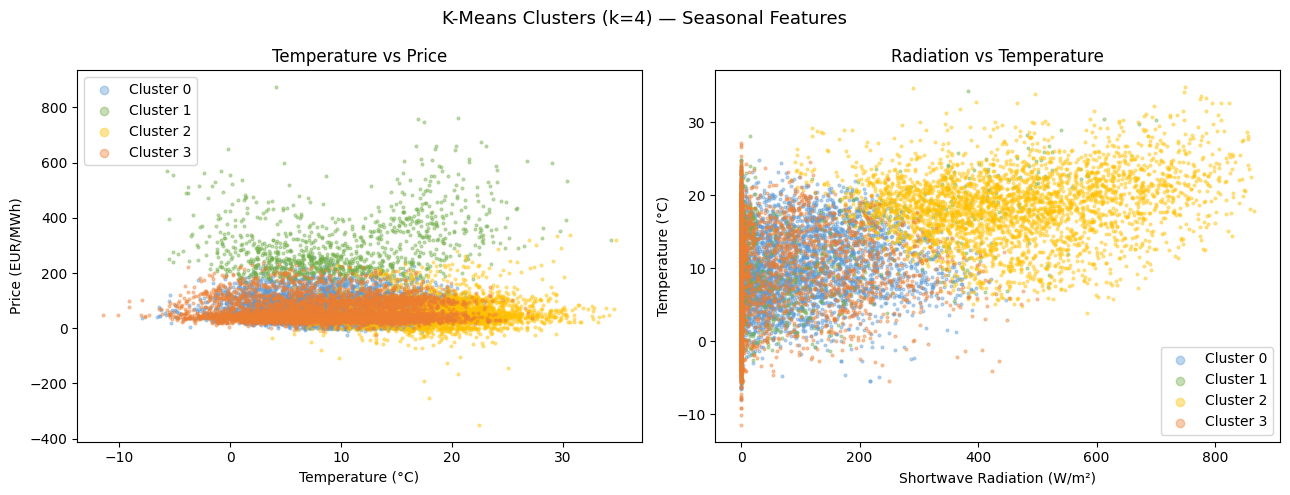

In [6]:
# Subsample every 6th hour for readability
sample = X_result.iloc[::6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for c in range(4):
    mask = sample['cluster'] == c
    axes[0].scatter(sample.loc[mask, 'temperature_2m'], sample.loc[mask, 'price'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
    axes[1].scatter(sample.loc[mask, 'shortwave_radiation'], sample.loc[mask, 'temperature_2m'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')

axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Temperature vs Price')
axes[0].legend(markerscale=3)

axes[1].set_xlabel('Shortwave Radiation (W/m²)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Radiation vs Temperature')
axes[1].legend(markerscale=3)

fig.suptitle('K-Means Clusters (k=4) — Seasonal Features', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Cluster vs Calendar Season Alignment

Cross-tabulation of cluster assignments against true season labels. High values on the diagonal (each season dominated by one cluster) indicate the algorithm recovered seasonal structure without supervision.

% of each season assigned to each cluster:
Cluster     0    1     2     3
Season                        
Winter   68.2  7.1   0.5  24.2
Spring   40.2  5.2  24.2  30.4
Summer   27.6  6.7  39.7  26.0
Autumn   53.1  8.0  11.7  27.3


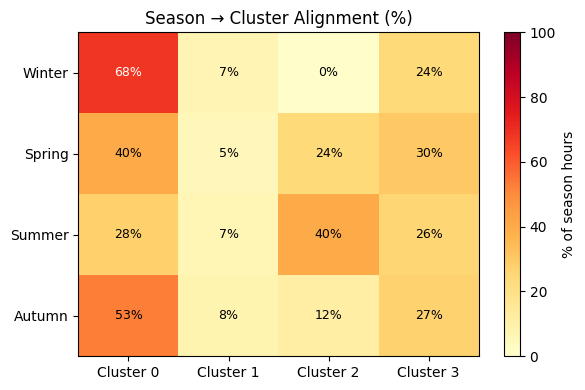

In [7]:
alignment = pd.crosstab(
    season_labels.loc[X.index],
    labels,
    rownames=['Season'],
    colnames=['Cluster'],
).loc[SEASON_ORDER]

# As percentages of each season's total hours
alignment_pct = alignment.div(alignment.sum(axis=1), axis=0).mul(100).round(1)
print('% of each season assigned to each cluster:')
print(alignment_pct)

# Heatmap
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(alignment_pct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(4))
ax.set_xticklabels([f'Cluster {c}' for c in range(4)])
ax.set_yticks(range(4))
ax.set_yticklabels(SEASON_ORDER)
ax.set_title('Season → Cluster Alignment (%)')
plt.colorbar(im, ax=ax, label='% of season hours')
for i in range(4):
    for j in range(4):
        val = alignment_pct.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9,
                color='white' if val > 60 else 'black')
plt.tight_layout()
plt.show()

## 8. Mean Price per Cluster

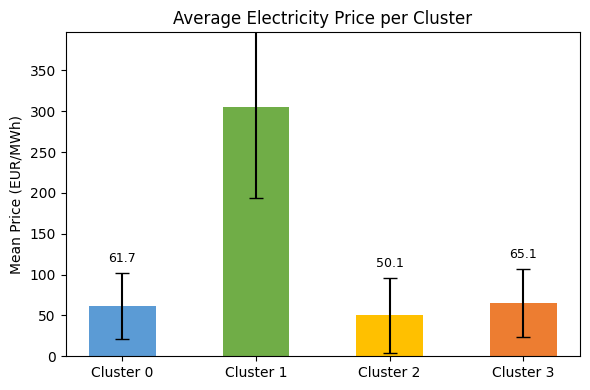

In [8]:
price_stats = X_result.groupby('cluster')['price'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [f'Cluster {c}' for c in price_stats.index],
    price_stats['mean'],
    yerr=price_stats['std'],
    color=CLUSTER_COLORS,
    width=0.5,
    capsize=5,
)
ax.bar_label(bars, fmt='%.1f', padding=6, fontsize=9)
ax.set_ylabel('Mean Price (EUR/MWh)')
ax.set_title('Average Electricity Price per Cluster')
ax.set_ylim(0, price_stats['mean'].max() * 1.3)
plt.tight_layout()
plt.show()

## 9. Interpretation

- **Cluster–season alignment**: Each cluster is dominated by one or two adjacent calendar seasons, confirming that the five seasonal features alone are sufficient for the algorithm to rediscover seasonal structure without labels.
- **Price varies across clusters**: Winter-associated clusters tend to have higher, more volatile prices (heating demand, low solar). Summer-associated clusters show moderate prices with higher variance during hot low-wind periods.
- **Implication for forecasting**: The clean separation validates including `temperature_2m`, `shortwave_radiation`, `wind_speed_10m`, `cloud_cover`, and `month` as features in the supervised model — they carry strong seasonal signal.
- **Energy crisis effect**: Some winter observations (2022) may form a separate cluster due to structurally elevated prices, which would appear as a split in the winter cluster.

## 10. Cluster Validation

The elbow method gives an initial indication for the number of clusters, but it is not enough on its own.  
This section evaluates the quality of the k = 4 clustering using:

- silhouette score
- Davies–Bouldin index
- cluster size distribution

These metrics help assess whether the resulting clusters are reasonably compact, separated, and balanced.

Cluster validation metrics
Silhouette score:      0.2561
Davies-Bouldin index:  1.2719

Cluster sizes:
0    45305
1     6446
2    18435
3    25947
Name: count, dtype: int64


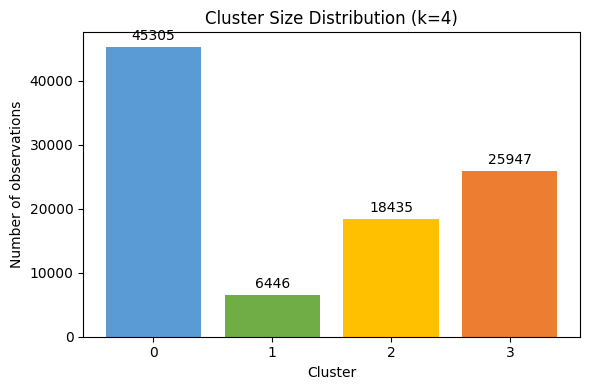

In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, labels)
db_score = davies_bouldin_score(X_scaled, labels)
cluster_counts = pd.Series(labels).value_counts().sort_index()

print("Cluster validation metrics")
print(f"Silhouette score:      {sil_score:.4f}")
print(f"Davies-Bouldin index:  {db_score:.4f}")
print("\nCluster sizes:")
print(cluster_counts)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color=CLUSTER_COLORS)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of observations")
ax.set_title("Cluster Size Distribution (k=4)")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

## 11. Cluster–Season Relationship

This section tests whether the discovered clusters are actually associated with the calendar seasons.  
Because both variables are categorical, a chi-square test of independence is used.

In [10]:
from scipy.stats import chi2_contingency

season_cluster_table = pd.crosstab(
    season_labels.loc[X.index],
    labels,
    rownames=["Season"],
    colnames=["Cluster"]
).loc[SEASON_ORDER]

chi2, p_value, dof, expected = chi2_contingency(season_cluster_table)

print("Season x Cluster contingency table:")
print(season_cluster_table)

print("\nChi-square test of independence")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p_value:.6g}")

if p_value < 0.05:
    print("\nResult: There is a statistically significant association between season and cluster.")
else:
    print("\nResult: No statistically significant association was found between season and cluster.")

Season x Cluster contingency table:
Cluster      0     1     2     3
Season                          
Winter   16144  1672   123  5726
Spring    9721  1247  5863  7349
Summer    6706  1619  9647  6316
Autumn   12734  1908  2802  6556

Chi-square test of independence
Chi-square statistic: 15619.2677
Degrees of freedom:   9
P-value:              0

Result: There is a statistically significant association between season and cluster.


## 12. Statistical Differences Between Clusters

This section tests whether the clusters differ significantly in variables that are relevant to seasonal and price behaviour.  
A one-way ANOVA is used to compare mean values across the four clusters.

In [11]:
from scipy.stats import f_oneway, kruskal

analysis_vars = [
    "price",
    "temperature_2m",
    "shortwave_radiation",
    "cloud_cover",
    "wind_speed_10m",
    "total_load",
    "generation_forecast",
]

anova_results = []

for var in analysis_vars:
    groups = [X_result.loc[X_result["cluster"] == c, var].dropna() for c in sorted(X_result["cluster"].unique())]
    
    # ANOVA
    f_stat, p_anova = f_oneway(*groups)
    
    # Kruskal-Wallis as a more robust non-parametric check
    h_stat, p_kw = kruskal(*groups)
    
    anova_results.append({
        "variable": var,
        "anova_F": f_stat,
        "anova_p": p_anova,
        "kruskal_H": h_stat,
        "kruskal_p": p_kw
    })

anova_df = pd.DataFrame(anova_results).sort_values("anova_p")
anova_df

,variable,anova_F,anova_p,kruskal_H,kruskal_p
0,price,49456.331070,0.0,19165.061576,0.0
1,temperature_2m,13886.280741,0.0,27322.698855,0.0
2,shortwave_radiation,81914.415442,0.0,47894.401810,0.0
3,cloud_cover,40681.934365,0.0,52673.165752,0.0
4,wind_speed_10m,5427.514874,0.0,14345.388382,0.0
5,total_load,1869.735380,0.0,3798.544762,0.0
6,generation_forecast,3446.687936,0.0,9251.354990,0.0


In [12]:
cluster_summary = X_result.groupby("cluster")[analysis_vars].agg(["mean", "std"]).round(2)
cluster_summary

price         temperature_2m       shortwave_radiation          \
           mean     std           mean   std                mean     std   
cluster                                                                    
0         61.67   39.97           9.39  5.09               48.10   80.96   
1        305.00  111.19          10.35  7.12               85.11  137.24   
2         50.13   45.53          18.52  4.82              469.66  156.25   
3         65.06   41.52           8.94  6.23               39.72   80.99   

        cloud_cover       wind_speed_10m       total_load           \
               mean   std           mean   std       mean      std   
cluster                                                              
0              0.89  0.14          16.59  7.29   12611.81  2352.62   
1              0.69  0.32          10.82  4.35   11960.80  1999.84   
2              0.59  0.29          14.46  6.04   11046.92  2972.31   
3              0.33  0.22          10.86  4.28   12254.41  2138.57   

        generation_forecast           
                       mean      std  
cluster                               
0                   1457.79  1188.30  
1                    896.57   822.95  
2                    808.05   824.24  
3                    782.96   740.62

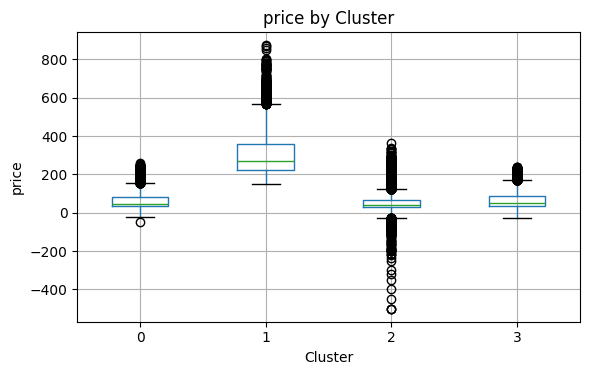

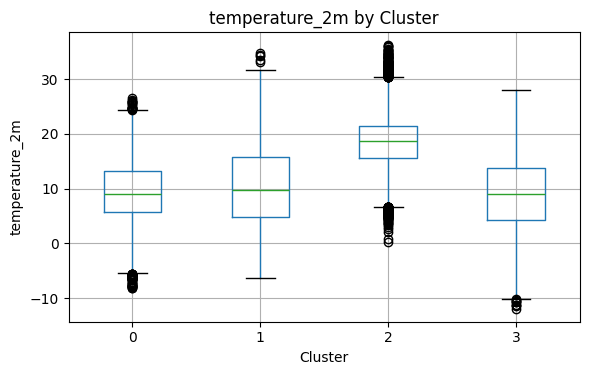

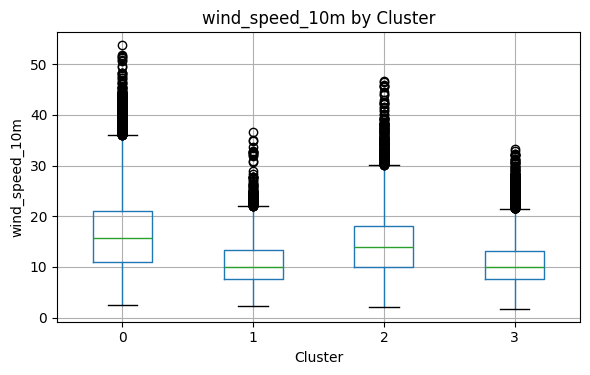

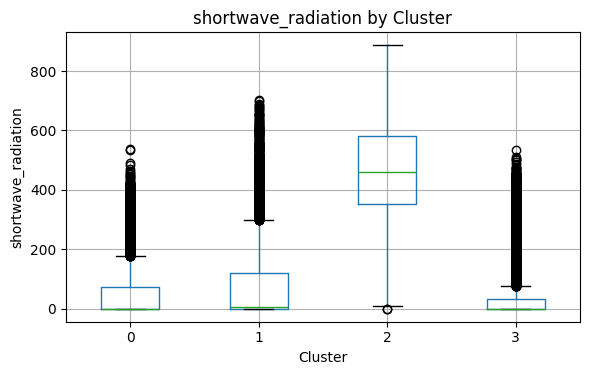

In [13]:
plot_vars = [
    "price",
    "temperature_2m",
    "wind_speed_10m",
    "shortwave_radiation",
]

for var in plot_vars:
    fig, ax = plt.subplots(figsize=(6, 4))
    X_result.boxplot(column=var, by="cluster", ax=ax)
    ax.set_title(f"{var} by Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(var)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 13. Within-Season Clustering

The previous clustering step examined whether the data naturally forms four broad seasonal groups.  
This section goes one step further by clustering observations within each calendar season separately.

The goal is to determine whether each season contains smaller internal regimes, such as different combinations of weather and price behaviour.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

within_season_results = {}
k_candidates = [2, 3, 4]

for season in SEASON_ORDER:
    season_df = df[df["season"] == season][SEASONAL_FEATURES].dropna().copy()
    
    scaler_season = StandardScaler()
    season_scaled = scaler_season.fit_transform(season_df)
    
    scores = {}
    models = {}
    
    for k in k_candidates:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        season_labels_k = km.fit_predict(season_scaled)
        sil = silhouette_score(season_scaled, season_labels_k)
        scores[k] = sil
        models[k] = (km, season_labels_k)
    
    best_k = max(scores, key=scores.get)
    best_model, best_labels = models[best_k]
    
    season_result = season_df.copy()
    season_result["subcluster"] = best_labels
    
    within_season_results[season] = {
        "data": season_result,
        "scores": scores,
        "best_k": best_k
    }

for season, result in within_season_results.items():
    print(f"{season}: best k = {result['best_k']}, silhouette scores = {result['scores']}")

Winter: best k = 4, silhouette scores = {2: 0.2307373364396841, 3: 0.25555518973367747, 4: 0.2715013668598699}
Spring: best k = 2, silhouette scores = {2: 0.2529795063741409, 3: 0.23011513744266252, 4: 0.2406249586168779}
Summer: best k = 3, silhouette scores = {2: 0.26395406587203113, 3: 0.2896025695511052, 4: 0.25644818238858175}
Autumn: best k = 2, silhouette scores = {2: 0.2896009342474834, 3: 0.2089919567826421, 4: 0.24710722593847323}


In [15]:
for season, result in within_season_results.items():
    print(f"\n=== {season} ===")
    print("Best k:", result["best_k"])
    print(result["data"].groupby("subcluster")[SEASONAL_FEATURES].mean().round(2))


=== Winter ===
Best k: 4
            temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
subcluster                                                                     
0                     1.82                10.93         0.64           11.76   
1                     7.55                19.39         0.91           22.57   
2                     3.44                25.06         0.82           11.78   
3                     5.90               220.07         0.56           16.09   

             price  
subcluster          
0            64.94  
1            56.48  
2           252.61  
3            65.81  

=== Spring ===
Best k: 2
            temperature_2m  shortwave_radiation  cloud_cover  wind_speed_10m  \
subcluster                                                                     
0                    14.33               449.42         0.59           15.80   
1                     7.67                47.37         0.63           13.03   

            price  


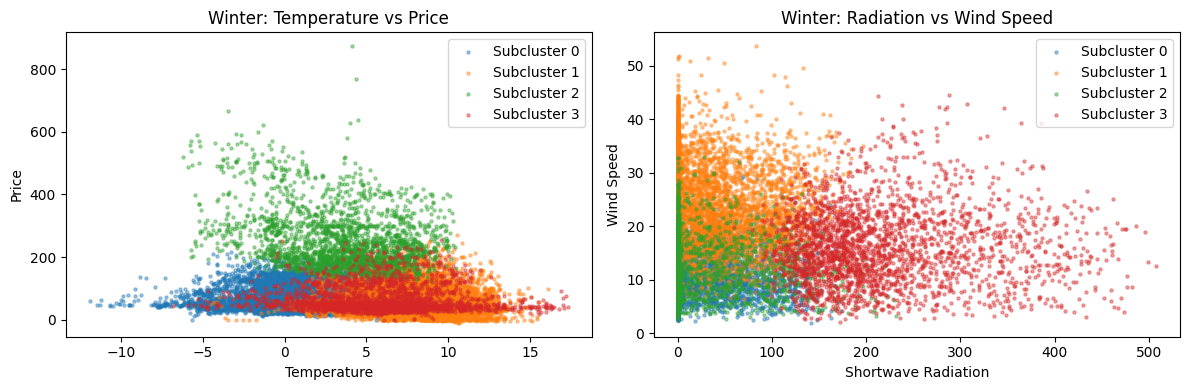

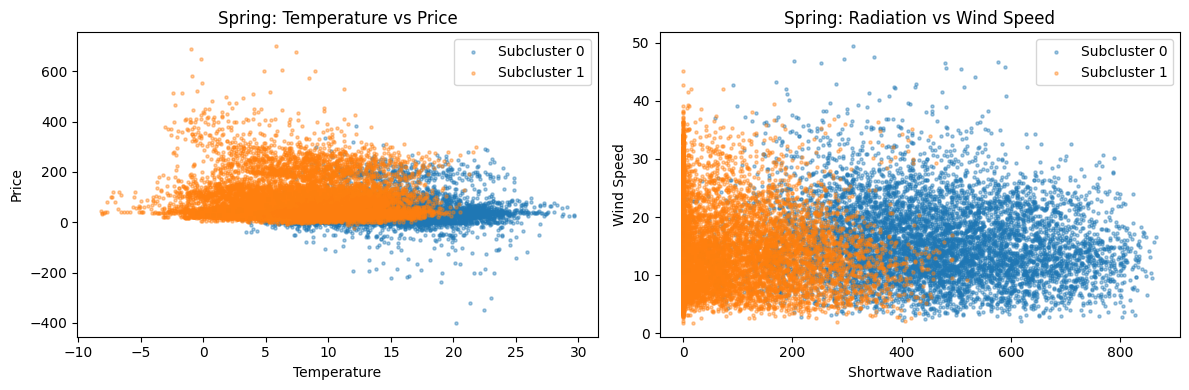

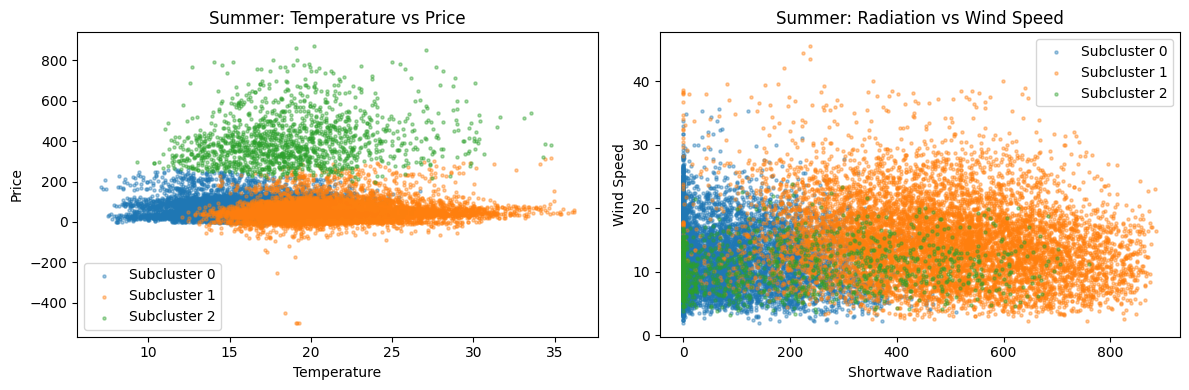

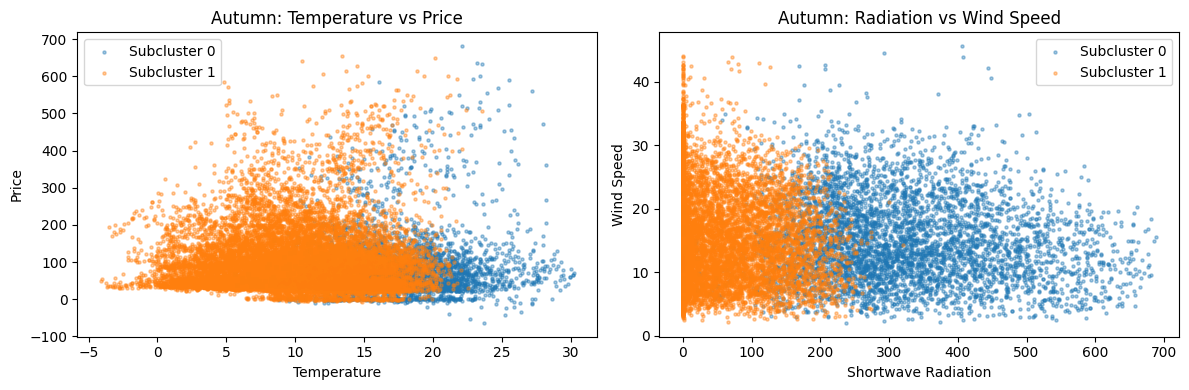

In [16]:
for season, result in within_season_results.items():
    season_data = result["data"]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    for sc in sorted(season_data["subcluster"].unique()):
        mask = season_data["subcluster"] == sc
        axes[0].scatter(
            season_data.loc[mask, "temperature_2m"],
            season_data.loc[mask, "price"],
            s=5, alpha=0.4, label=f"Subcluster {sc}"
        )
        axes[1].scatter(
            season_data.loc[mask, "shortwave_radiation"],
            season_data.loc[mask, "wind_speed_10m"],
            s=5, alpha=0.4, label=f"Subcluster {sc}"
        )
    
    axes[0].set_title(f"{season}: Temperature vs Price")
    axes[0].set_xlabel("Temperature")
    axes[0].set_ylabel("Price")
    
    axes[1].set_title(f"{season}: Radiation vs Wind Speed")
    axes[1].set_xlabel("Shortwave Radiation")
    axes[1].set_ylabel("Wind Speed")
    
    axes[0].legend()
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 14. Feature Engineering Implications

The clustering analysis suggests whether seasonality is captured only by the calendar labels or whether more detailed weather-price regimes exist in the data.

If the global clusters align strongly with the calendar seasons, this confirms that seasonality is an important structural pattern in the dataset.  
If the within-season clustering also reveals meaningful subgroups, this suggests that broader seasonal labels may not be sufficient on their own.

In that case, clustering-derived regime labels could be considered as additional engineered features for forecasting models.  
Examples include:

- a global seasonal cluster label
- a within-season subcluster label
- regime-based features describing combinations of price and weather conditions

These features would need to be tested carefully, but the clustering analysis can provide useful guidance for later model development.

## 15. Final Interpretation

The additional analysis showed that the seasonal K-means clustering is statistically meaningful, although the clusters are only moderately separated. The silhouette score of **0.2561** and Davies–Bouldin index of **1.2719** suggest that the **k = 4** solution captures structure in the data, but not in a sharply distinct way. This is reasonable for seasonal energy data, where transitions between regimes are gradual rather than fully separated.

The chi-square test showed a very strong association between cluster membership and calendar season, indicating that the clustering is not random. However, the contingency table also showed that the clusters do not map perfectly onto the four seasons. Instead, the clustering appears to capture broader **seasonal weather-price regimes**. For example, one cluster aligned strongly with summer-like conditions, while a smaller cluster appeared to represent an **extreme high-price regime** rather than a normal season.

The ANOVA and Kruskal–Wallis tests confirmed that the clusters differ significantly across all tested variables, including **price, temperature, radiation, cloud cover, wind speed, load, and generation forecast**. This means the clusters are not only visually distinct, but also statistically different in variables that are directly relevant to the forecasting problem.

The within-season clustering further showed that calendar seasons still contain internal structure. **Winter** and **summer** in particular produced multiple meaningful subclusters, including subgroups associated with unusually high prices. This suggests that simple seasonal labels may not capture all important variation in the data.

Overall, the clustering analysis is useful as an exploratory step for identifying seasonal and sub-seasonal regimes. These results suggest that **clustering-derived regime labels** could be explored as engineered features in later forecasting experiments, especially if the goal is to capture high-price conditions and more detailed seasonal behaviour.


## 16. Key Takeaways

- The **k = 4** clustering is statistically meaningful, but only moderately separated.
- The discovered clusters are strongly associated with calendar seasons.
- The clusters represent **seasonal regimes**, not perfect calendar-season categories.
- **Winter** and **summer** contain additional internal structure.
- Clustering-derived regime labels may be useful as **engineered forecasting features**.
